In [2]:
import pandas as pd
df = pd.read_csv("../data/student_performance.csv")
print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (1000, 7)


,study_hours,attendance,previous_score,sleep_hours,assignment_completion,extracurricular,final_score
0,4.37,59.26,54.39,7.36,74.32,0,61.39
1,9.56,77.10,53.58,7.98,88.33,1,85.40
2,7.59,93.65,89.84,5.25,85.61,0,89.68
3,6.39,86.61,53.73,7.12,49.23,1,65.84
4,2.40,90.33,54.96,6.86,48.95,1,59.18


In [3]:
print("Dataset Shape:", df.shape)
print("\n Columns:")
print(df.columns.tolist())
print("\n Missing Values:")
print(df.isnull().sum())

Dataset Shape: (1000, 7)

 Columns:
['study_hours', 'attendance', 'previous_score', 'sleep_hours', 'assignment_completion', 'extracurricular', 'final_score']

 Missing Values:
study_hours              0
attendance               0
previous_score           0
sleep_hours              0
assignment_completion    0
extracurricular          0
final_score              0
dtype: int64


In [4]:
df.describe()

,study_hours,attendance,previous_score,sleep_hours,assignment_completion,extracurricular,final_score
count,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,5.412390,75.35080,67.632270,6.451840,69.646320,0.511000,73.358560
std,2.629218,14.60942,15.986885,1.432386,17.208533,0.500129,10.519865
min,1.040000,50.16000,40.000000,4.000000,40.000000,0.000000,41.710000
25%,3.127500,62.05250,54.372500,5.210000,54.697500,0.000000,66.465000
50%,5.475000,75.93500,67.530000,6.420000,69.675000,1.000000,73.070000
75%,7.702500,88.02000,81.755000,7.690000,84.400000,1.000000,80.700000
max,10.000000,99.97000,94.880000,9.000000,99.860000,1.000000,100.000000


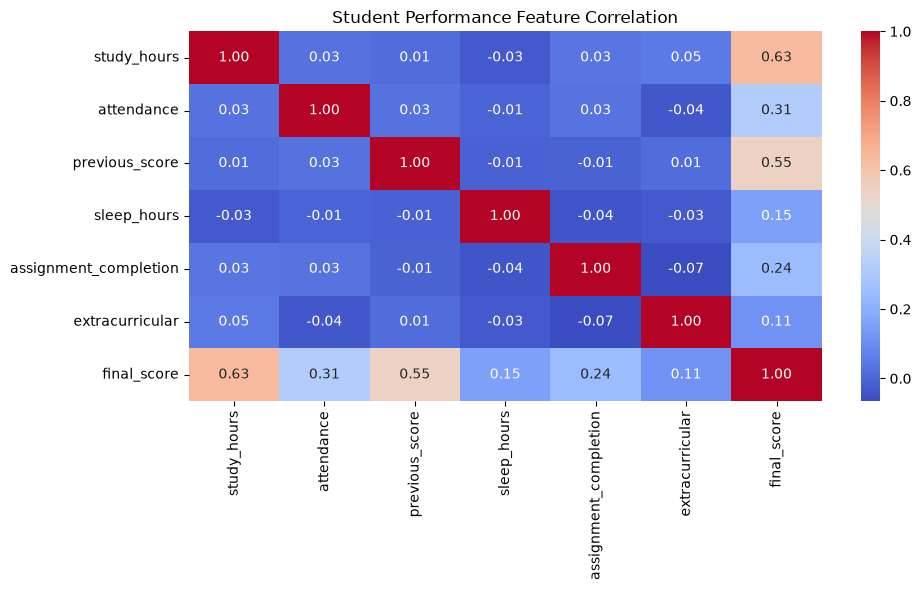

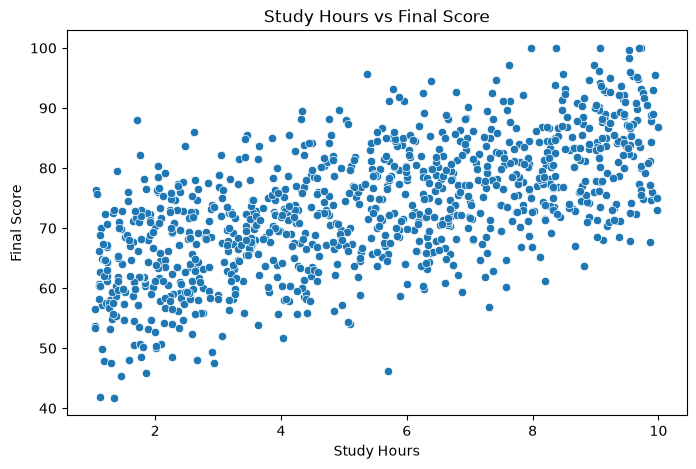

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# Correlation Heatmap
plt.figure(figsize=(10, 6))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Student Performance Feature Correlation")
plt.tight_layout()
plt.show()


# Study Hours vs Final Score
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="study_hours",
    y="final_score"
)

plt.title("Study Hours vs Final Score")
plt.xlabel("Study Hours")
plt.ylabel("Final Score")

plt.show()

In [10]:
X = df.drop("final_score", axis= 1)
y = df["final_score"]
print("Features:")
print(X.columns.tolist())
print("\n Target:")
print(y.name)

Features:
['study_hours', 'attendance', 'previous_score', 'sleep_hours', 'assignment_completion', 'extracurricular']

 Target:
final_score


In [11]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y, 
    test_size =0.2,
    random_state = 42
)
print("Training samples:", X_train.shape[0])
print("Testin samples:", X_test.shape[0])

Training samples: 800
Testin samples: 200


In [12]:
from sklearn.linear_model import LinearRegression
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)
print("Linear Regression model trained successfully!")

Linear Regression model trained successfully!


In [13]:
linear_predictions = linear_model.predict(X_test)
print("First 10 predictions:")
print(linear_predictions[:10])

First 10 predictions:
[69.90341442 77.62772895 77.10406246 69.91406786 66.81951453 75.65049413
 57.89841516 81.29587704 64.67322135 72.03230347]


In [17]:
import numpy as np

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

linear_mae = mean_absolute_error(
    y_test,
    linear_predictions
)

linear_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        linear_predictions
    )
)

linear_r2 = r2_score(
    y_test,
    linear_predictions
)

print("Linear Regression Results")
print("-------------------------")
print(f"MAE  : {linear_mae:.2f}")
print(f"RMSE : {linear_rmse:.2f}")
print(f"R²   : {linear_r2:.4f}")

Linear Regression Results
-------------------------
MAE  : 2.91
RMSE : 3.69
R²   : 0.8785


In [20]:
from sklearn.tree import DecisionTreeRegressor

tree_model = DecisionTreeRegressor(
    max_depth = 5,
    random_state= 42
)

tree_model.fit(X_train, y_train)

tree_predictions = tree_model.predict(X_test)
tree_mae = mean_absolute_error(
    y_test,
    tree_predictions
)

tree_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        tree_predictions
    )
)

tree_r2 = r2_score(
    y_test,
    tree_predictions
)

print("Decision Tree Regression Results")
print("--------------------------------")
print(f"MAE  : {tree_mae:.2f}")
print(f"RMSE : {tree_rmse:.2f}")
print(f"R²   : {tree_r2:.4f}")

Decision Tree Regression Results
--------------------------------
MAE  : 4.92
RMSE : 6.07
R²   : 0.6719


In [21]:
from sklearn.ensemble import RandomForestRegressor

forest_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

forest_model.fit(X_train, y_train)

forest_predictions = forest_model.predict(X_test)

forest_mae = mean_absolute_error(
    y_test,
    forest_predictions
)

forest_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        forest_predictions
    )
)

forest_r2 = r2_score(
    y_test,
    forest_predictions
)

print("Random Forest Regression Results")
print("--------------------------------")
print(f"MAE  : {forest_mae:.2f}")
print(f"RMSE : {forest_rmse:.2f}")
print(f"R²   : {forest_r2:.4f}")

Random Forest Regression Results
--------------------------------
MAE  : 3.53
RMSE : 4.44
R²   : 0.8244


In [22]:
results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "MAE": [
        linear_mae,
        tree_mae,
        forest_mae
    ],
    "RMSE": [
        linear_rmse,
        tree_rmse,
        forest_rmse
    ],
    "R2": [
        linear_r2,
        tree_r2,
        forest_r2
    ]
})

results

,Model,MAE,RMSE,R2
0,Linear Regression,2.908071,3.690023,0.878549
1,Decision Tree,4.917060,6.065188,0.671881
2,Random Forest,3.527939,4.436608,0.824432


In [23]:
import joblib
import os

os.makedirs("../models", exist_ok=True)

model_path = "../models/student_performance_model.pkl"

joblib.dump(linear_model, model_path)

print("Best model saved successfully!")
print(f"Model path: {model_path}")

Best model saved successfully!
Model path: ../models/student_performance_model.pkl
